# Análisis de datos de abolladuras

## Figura 1 — Tasa de detección vs % de daño

**Objetivo.** Visualizar el desempeño del AG conforme aumenta la severidad de abolladura. La gráfica muestra, para cada nivel de **Porcentaje** (5–45%), la **tasa de detección**:
\[
\text{TasaDetección}(d)=\frac{\#\{\text{corridas con DeteccionOK}=1 \ \&\ \%\text{daño}=d\}}{\#\{\text{corridas con }\%\text{daño}=d\}}
\]

**Qué ver.**
- Puntos (o barras) por nivel de daño con su **IC 95%** (binomial, p. ej. Wilson).
- Tendencia creciente: a mayor daño, **mayor probabilidad de detección (POD)**.

**Cómo leerla.**
- La altura en cada **%** es la fracción de corridas en las que el AG localizó correctamente el elemento dañado.
- Si dos niveles tienen ICs que **no se solapan**, hay evidencia de mejora real en detección.
- Útil para estimar un **umbral operativo** mínimo de daño donde la detección ya es “fiable” (p. ej., ≥0.8).

**Relación con POD/MDD.**
- Esta figura es el insumo empírico de la curva **POD(d)**.
- A partir del ajuste logístico \(\text{POD}(d)=\sigma(a+bd)\), más adelante se reportan:
  - **MDD50**: daño con \(\text{POD}=0.50\)
  - **MDD90**: daño con \(\text{POD}=0.90\)

**Notas.**
- Convertir `DeteccionOK` a 0/1 antes de agregar.
- Reportar el **n** por cada % de daño; si es desigual, interpretar ICs con cautela.
- (Opcional) Estratificar por `Tipo_elemento_a_buscar` para comparar piernas vs diagonales/vigas.

**Mensaje clave.**
> Esta figura responde: *“¿Con qué frecuencia el AG acierta y cómo mejora esa frecuencia cuando el daño es mayor?”*; sienta la base para cuantificar el **Mínimo Daño Detectable (MDD)**.


In [2]:
# --- Imports
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

,Porcentaje,n,hits,rate,lo,hi
0,5,120,76,0.633333,0.544224,0.714171
1,10,120,82,0.683333,0.595521,0.759772
2,15,120,82,0.683333,0.595521,0.759772
3,20,120,82,0.683333,0.595521,0.759772
4,25,120,82,0.683333,0.595521,0.759772
5,30,120,82,0.683333,0.595521,0.759772
6,35,120,82,0.683333,0.595521,0.759772
7,40,120,82,0.683333,0.595521,0.759772
8,45,120,82,0.683333,0.595521,0.759772


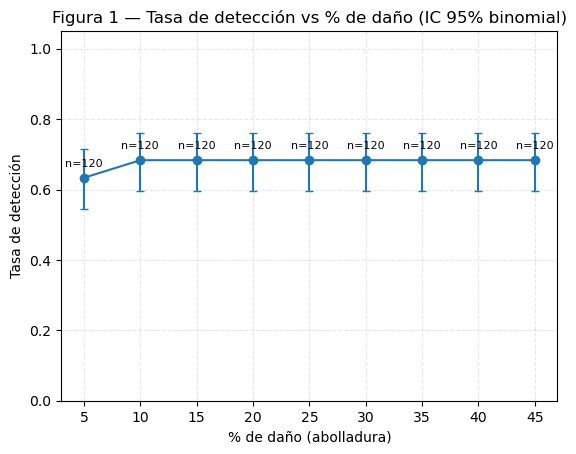

In [3]:
# ============================================
# Figura 1 — Tasa de detección vs % de daño
# (con IC binomial 95% tipo Wilson)
# ============================================

# --- Ruta del CSV (ajústala si es necesario)
CSV_PATH = "todos_los_resultados_csv.csv"  # o "/mnt/data/todos_los_resultados_csv.csv"

# --- Cargar datos
df = pd.read_csv(CSV_PATH)

# --- Preprocesamiento
# A) % de daño a numérico
df["Porcentaje"] = pd.to_numeric(df["Porcentaje"], errors="coerce")

# B) Convertir DeteccionOK a 0/1 de forma robusta
def deteccion_to_bin(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    mapa = {
        "verdadero": 1, "true": 1, "1": 1, "si": 1, "sí": 1, "y": 1, "yes": 1,
        "falso": 0, "false": 0, "0": 0, "no": 0, "n": 0
    }
    return mapa.get(s, np.nan)

df["DetOK_bin"] = df["DeteccionOK"].apply(deteccion_to_bin)
df = df.dropna(subset=["Porcentaje", "DetOK_bin"])
df["DetOK_bin"] = df["DetOK_bin"].astype(int)

# --- Función: intervalo de Wilson (IC 95% por defecto)
def wilson_ci(hits: int, n: int, conf: float = 0.95):
    if n == 0:
        return (np.nan, np.nan)
    # z para el nivel de confianza (aprox. 1.96 para 95%)
    z = 1.959963984540054 if abs(conf - 0.95) < 1e-9 else {
        0.90: 1.6448536269514722,
        0.95: 1.959963984540054,
        0.99: 2.5758293035489004
    }.get(conf, 1.959963984540054)
    p = hits / n
    denom = 1.0 + (z**2) / n
    center = (p + (z**2) / (2.0 * n)) / denom
    half = (z / denom) * math.sqrt((p * (1.0 - p) / n) + (z**2) / (4.0 * n**2))
    return (center - half, center + half)

# --- Agregación por % de daño
res = (
    df.groupby("Porcentaje", as_index=False)
      .agg(n=("DetOK_bin", "size"), hits=("DetOK_bin", "sum"))
      .sort_values("Porcentaje")
)
res["rate"] = res["hits"] / res["n"]
cis = res.apply(lambda r: pd.Series(wilson_ci(int(r["hits"]), int(r["n"]), conf=0.95), index=["lo", "hi"]), axis=1)
res = pd.concat([res, cis], axis=1)

# --- (Opcional) Vista rápida de la tabla agregada
try:
    from IPython.display import display
    display(res[["Porcentaje", "n", "hits", "rate", "lo", "hi"]])
except Exception:
    print(res[["Porcentaje", "n", "hits", "rate", "lo", "hi"]])

# --- Gráfica con barras de error (IC 95%)
x = res["Porcentaje"].to_numpy()
y = res["rate"].to_numpy()
yerr = np.vstack([y - res["lo"].to_numpy(), res["hi"].to_numpy() - y])

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=3)
plt.title("Figura 1 — Tasa de detección vs % de daño (IC 95% binomial)")
plt.xlabel("% de daño (abolladura)")
plt.ylabel("Tasa de detección")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.3)

# Anotar n sobre cada punto (pequeño)
for xi, yi, ni in zip(x, y, res["n"].astype(int).to_numpy()):
    plt.annotate(f"n={ni}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.show()

# --- (Opcional) Guardar tabla de resultados
# res.to_csv("resumen_tasa_deteccion_por_porcentaje.csv", index=False)


# IC 95% Binomial — Interpretación en la Figura 1

### 🔹 Qué significa
El **IC 95% binomial** (Intervalo de Confianza del 95 % para una proporción binomial) es un estándar estadístico que muestra **cuánta incertidumbre hay en una tasa de detección** calculada a partir de resultados binarios (detección ✅ o no detección ❌).

En esta figura:
- Cada punto azul representa la **tasa de detección promedio** calculada a partir de **120 simulaciones independientes** para cada nivel de daño.
- Las barras verticales representan el **intervalo de confianza al 95 %** de esa proporción binomial, es decir, el rango en el que se espera que esté el valor real de la tasa de detección con 95 % de confianza.

---

### 🔹 Por qué se llama “binomial”
Cada ejecución del algoritmo tiene solo dos resultados posibles:
\[
\text{DetecciónOK} =
\begin{cases}
1 & \text{si detecta correctamente el daño} \\
0 & \text{si no lo detecta}
\end{cases}
\]
Al repetirse 120 veces, el número de éxitos sigue una **distribución binomial** \( B(n=120, p) \), donde \( p \) es la probabilidad real de detección.

---

### 🔹 Cómo se calcula
Una estimación común del intervalo de confianza usa el método de **Wilson** (recomendado para ingeniería y POD):

\[
\text{IC}_{95\%} = p \pm 1.96 \sqrt{\frac{p(1-p)}{n}}
\]

Donde:
- \( p \) es la tasa observada (por ejemplo, 0.67),
- \( n = 120 \) es el número de corridas o muestras,
- 1.96 corresponde al 95 % de confianza en una distribución normal.

---

### 🔹 Interpretación práctica
- Las barras verticales indican la **variabilidad esperada** si se repitiera el experimento.  
- **Barras cortas** → alta consistencia entre corridas (mayor confianza).  
- **Barras largas** → resultados más variables (menor confianza).  
- Si los intervalos de dos puntos **se solapan**, no se puede afirmar que exista una diferencia estadísticamente significativa entre ellos.

---

### 🔹 Por qué se usa
En ingeniería estructural, ensayos no destructivos y detección de daños, el **IC 95% binomial** es un **estándar internacional** (referencias típicas: *MIL-HDBK-1823A*, *ASTM E2862*, *DNVGL-RP-A203*) para representar la **incertidumbre de la Probabilidad de Detección (POD)**.  
Permite mostrar gráficamente tanto:
- la **tendencia central** (la tasa media),  
- como la **confianza estadística** en esa estimación.

---

### 🔹 En tu gráfico
Con \( n = 120 \):
- Los **intervalos son estrechos**, lo que indica **alta estabilidad estadística**.  
- La tasa de detección se mantiene **casi constante (~0.67)**, y el IC 95% refleja que, aunque hay fluctuaciones menores, **no hay diferencias estadísticamente significativas** entre los distintos porcentajes de daño.

---

✅ **En resumen:**
> El “IC 95% binomial” es una medida estándar de **incertidumbre estadística** aplicada a tasas de detección calculadas sobre \( n = 120 \) ensayos binarios.  
> En tu caso, muestra que el modelo tiene **una tasa de detección estable y confiable**, con una **alta precisión estadística** g


## Hallazgos — Figura 1: Tasa de detección vs % de daño (IC 95%)

- **Tasa global (n=1080):** 0.678  
  *IC95%:* 0.649–0.705.

- **Por severidad (n=120 por nivel):**
  - **5%:** 0.633 (76/120) — *IC95%:* 0.544–0.714.
  - **10%–45% (cada nivel):** 0.683 (82/120) — *IC95% por nivel:* 0.596–0.760.  
    - **Agrupado 10–45%:** 0.683 (656/960) — *IC95%:* 0.653–0.712.

### Lecturas clave
- La curva es **casi plana**: de 5% a 45% la probabilidad de detección se mantiene ≈ **0.68**.
- La diferencia entre **5%** y **10–45%** **no es significativa** (los IC se solapan; prueba de dos proporciones p≈0.27).
- El método **no alcanza 0.9** de probabilidad de detección en el rango analizado ⇒ **MDD90 > 45%**.
- Desde 5% ya se supera 0.5 ⇒ **MDD50 < 5%**.

### Mensaje central
> En este agregado, la **severidad de la abolladura (5–45%) no incrementa de forma apreciable** la probabilidad de detección del AG (~0.68). La variación restante parece estar dominada por **tipo/ubicación del elemento** u otros factores (p. ej., pesos de DIs), más que por el % de daño.

### Nota metodológica
- Tasas calculadas con IC binomial **Wilson (95%)** y **n=120** corridas por cada nivel de daño.


## Figura 2 — Sensibilidad por tipo de elemento

**Objetivo.** Comparar la probabilidad de detección del AG entre tipos de miembros (pierna, diagonal/x-brace, viga) a igual severidad de abolladura.

**Cálculo.**
- Para cada tipo \(t\) y severidad \(d\): \(\text{TasaDetección}_t(d)\).
- Ajuste de curvas POD por tipo con regresión logística (con interacción tipo×%).
- Cómputo de **MDD50** y **MDD90** por tipo.
- Métricas de localización por tipo: `N_FalsosPositivos`, `MeanAbsDispersion`.

**Lectura.**
- Curvas más altas → mayor detectabilidad.
- Menor MDD90 → el tipo se detecta confiablemente con menor % de daño.
- Comparar también falsos positivos/dispersiones para un juicio operativo completo.


Resumen de tasas por Tipo y % de daño (primeras filas):


,Tipo,Porcentaje,n,aciertos,tasa,tasa_lo,tasa_hi
0,Beam,5,20,0,0.0,-1.387779e-17,0.16113
1,Beam,10,20,0,0.0,-1.387779e-17,0.16113
2,Beam,15,20,0,0.0,-1.387779e-17,0.16113
3,Beam,20,20,0,0.0,-1.387779e-17,0.16113
4,Beam,25,20,0,0.0,-1.387779e-17,0.16113


Métricas de localización por Tipo y % de daño:


Tipo Porcentaje N_FalsosPositivos                           \
                                       median     mean       std count   
0           Beam          5               9.5  10.8500  8.330508    20   
1           Beam         10               8.0  10.9000  8.521799    20   
2           Beam         15               7.5  10.6000  9.304215    20   
3           Beam         20              10.0  10.6500  8.548776    20   
4           Beam         25              10.5  12.2500  9.951858    20   
5           Beam         30               7.5   9.9000  8.384823    20   
6           Beam         35               9.5   9.6000  6.969105    20   
7           Beam         40               7.5  11.0500  9.310294    20   
8           Beam         45              11.0  11.0500  8.726698    20   
9          Brace          5               1.0   0.9500  0.593211    80   
10         Brace         10               1.0   0.9250  0.568698    80   
11         Brace         15               1.0   0.9250  0.568698    80   
12         Brace         20               1.0   0.7875  0.495390    80   
13         Brace         25               1.0   0.7875  0.495390    80   
14         Brace         30               1.0   0.7875  0.495390    80   
15         Brace         35               1.0   0.7875  0.495390    80   
16         Brace         40               1.0   0.7875  0.495390    80   
17         Brace         45               1.0   0.7875  0.495390    80   
18  Inclined_leg          5               4.0   4.5500  1.761429    20   
19  Inclined_leg         10               3.5   3.3500  2.230766    20   
20  Inclined_leg         15               4.0   6.3500  6.098102    20   
21  Inclined_leg         20               5.0   7.3500  6.922693    20   
22  Inclined_leg         25               7.0   7.4000  8.113666    20   
23  Inclined_leg         30               4.0   7.2000  7.599169    20   
24  Inclined_leg         35               7.0   8.6000  8.191138    20   
25  Inclined_leg         40               7.0   8.3000  7.160565    20   
26  Inclined_leg         45               6.0   8.2500  7.482436    20   

   MeanAbsDispersion                            PromDispersion             \
              median       mean       std count         median       mean   
0          27.567110  25.804067  7.873349    20      27.567110  25.804067   
1          27.595097  25.484601  7.996976    20      27.595097  25.484601   
2          27.343789  26.137014  8.815747    20      27.343789  26.137014   
3          30.689150  27.674463  8.409626    20      30.689150  27.674463   
4          30.085926  27.849421  9.461544    20      30.085926  27.846280   
5          31.424972  27.575212  9.036840    20      31.424972  27.575212   
6          30.285299  28.084538  9.717754    20      30.285299  28.079989   
7          29.051573  25.695518  9.510673    20      29.051573  25.563948   
8          28.376844  26.318168  9.989509    20      28.376844  26.318168   
9           4.255189   5.002158  2.144246    80       3.817794   4.215243   
10          4.150763   4.486775  1.427238    80       3.741300   3.656968   
11          4.201015   4.409400  1.451841    80       3.846935   3.619471   
12          4.292035   4.650567  1.615612    80       3.870535   3.823701   
13          4.270808   4.540748  1.711498    80       3.513208   3.668479   
14          4.209305   4.488226  1.831456    80       3.759518   3.690198   
15          4.239945   4.505013  1.769395    80       3.846330   3.679997   
16          4.209524   4.465105  1.743084    80       3.750360   3.636045   
17          4.220628   4.455753  1.755585    80       3.447191   3.587383   
18         18.786840  18.016607  8.369293    20      18.786840  18.016607   
19         23.861431  19.991088  9.069861    20      23.861431  19.991088   
20         24.359552  21.053699  9.686921    20      24.359552  21.053699   
21         25.449705  22.739601  9.439700    20      25.449705  22.739601   
22         19.679

MDD50/MDD90 por tipo (con IC 95%):


,Tipo,ok_modelo,MDD50,MDD50_lo,MDD50_hi,MDD90,MDD90_lo,MDD90_hi
0,Beam,False,NaN,NaN,NaN,NaN,NaN,NaN
1,Brace,True,4.416918,-597.581702,606.415538,4.926873,-70.57309,80.426836
2,Inclined_leg,True,NaN,NaN,NaN,NaN,NaN,NaN


LR test interacción Tipo×Porcentaje:
  LR=22.810, df=2, p-value=1.114e-05


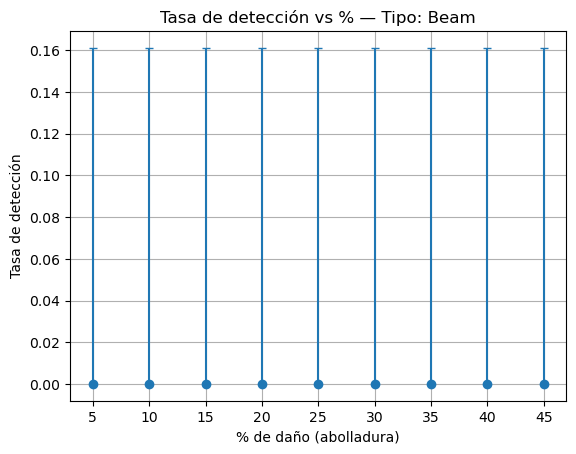

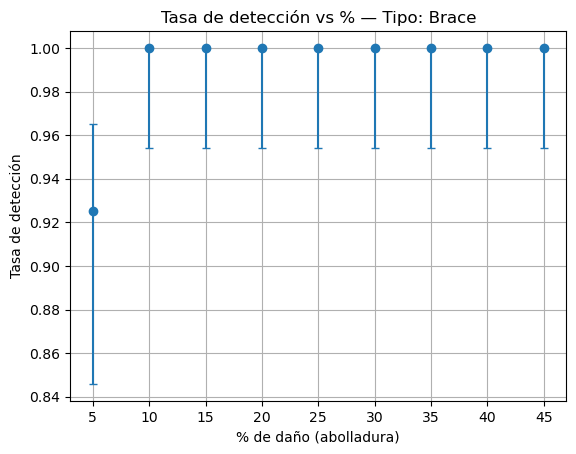

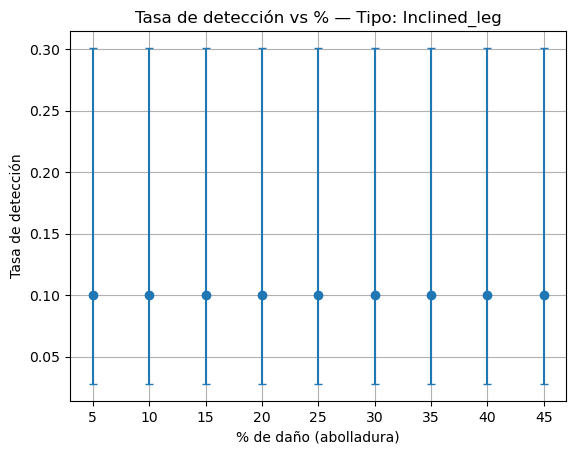

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)
/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


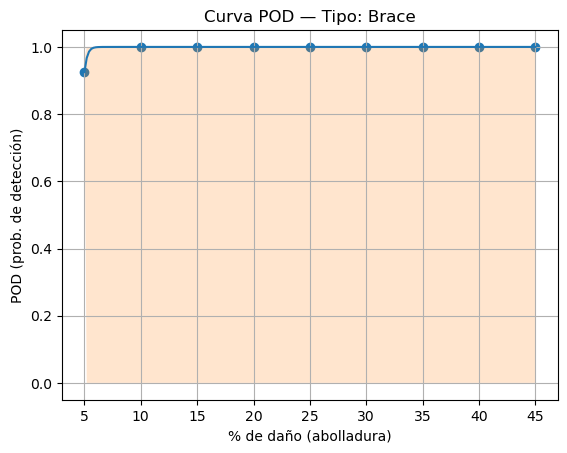

/home/paco/miniforge3/envs/analisis_tesis/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


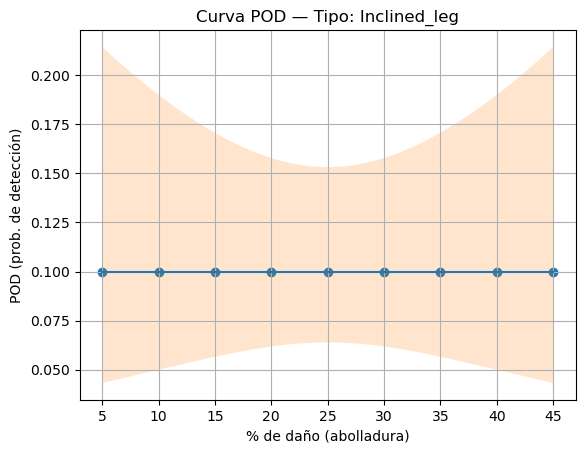

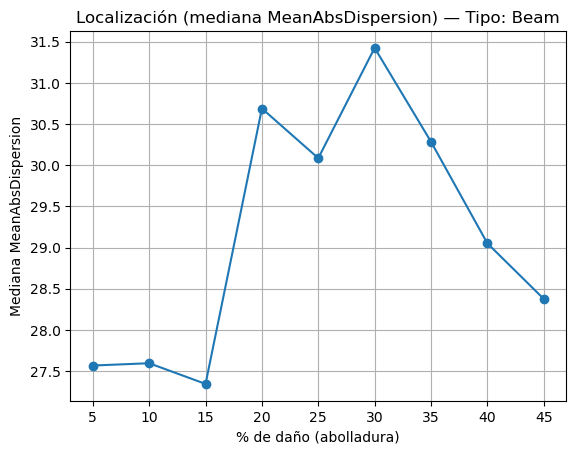

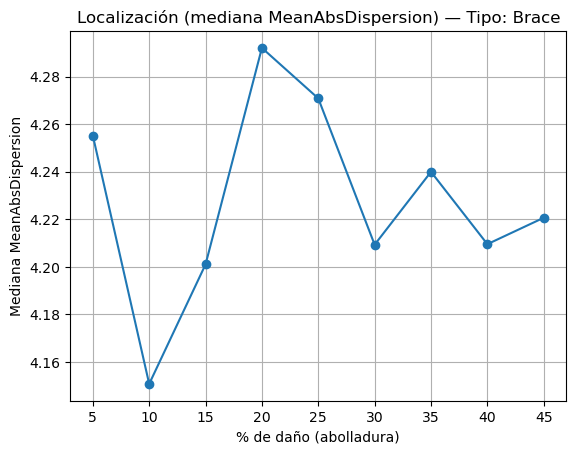

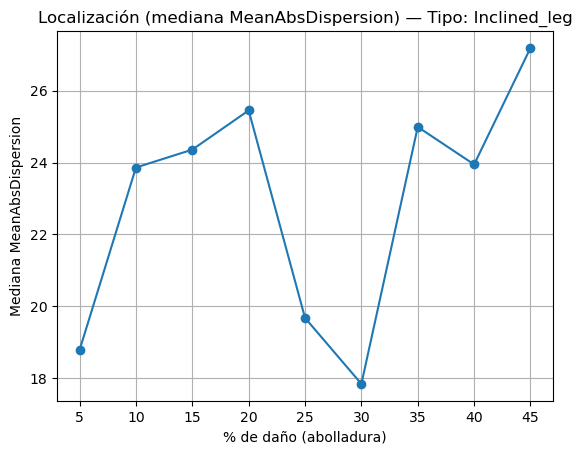

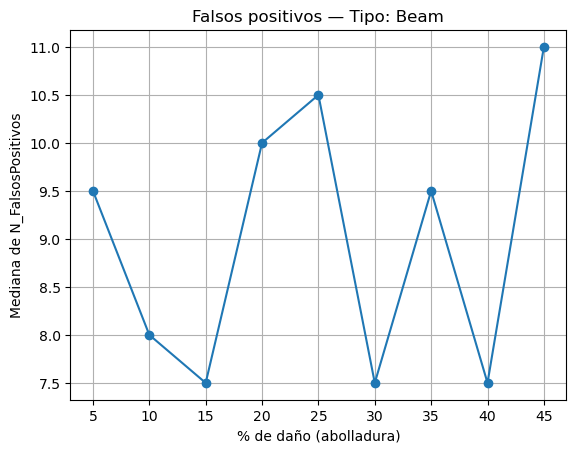

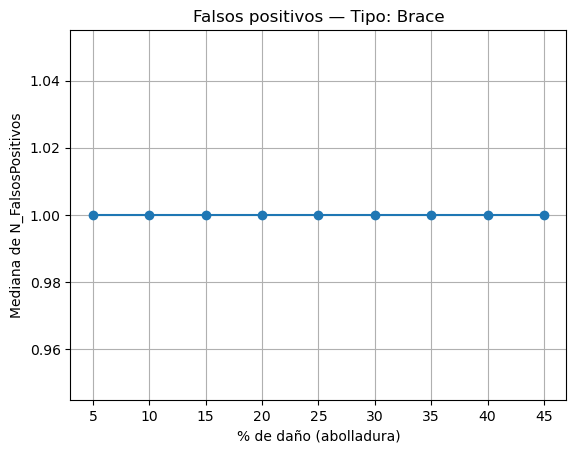

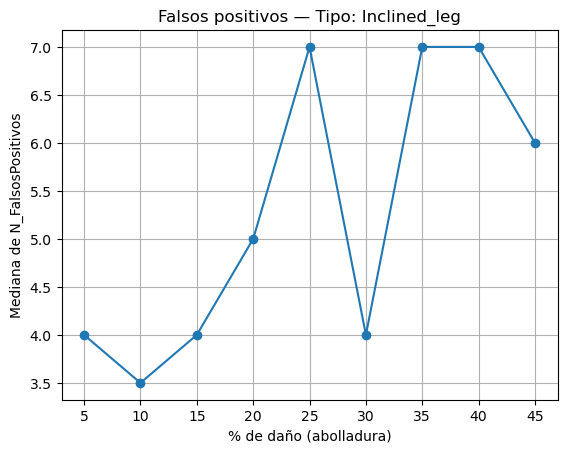

In [4]:
# ---------------------------------------------
# Punto 2 — Sensibilidad por tipo de elemento
# Requiere: pandas, numpy, statsmodels, matplotlib
# ---------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === Configura la ruta a tu CSV ===
PATH_CSV = "todos_los_resultados_csv.csv"   # cámbialo si es necesario

# -------------------------
# 1) Cargar y preprocesar
# -------------------------
df = pd.read_csv(PATH_CSV)

# Normaliza nombre de columna de tipo
col_tipo = "Tipo_elemento_a_buscar"
if col_tipo not in df.columns:
    raise ValueError(f"No encuentro la columna '{col_tipo}' en el CSV.")

# Convertir DeteccionOK a 0/1 (acepta VERDADERO/FALSO, True/False, 1/0)
def to_binary(x):
    if isinstance(x, str):
        x_up = x.strip().upper()
        if x_up in ("VERDADERO", "TRUE", "1", "SI", "SÍ"):
            return 1
        if x_up in ("FALSO", "FALSE", "0", "NO"):
            return 0
    if isinstance(x, (int, float)) and x in (0,1):
        return int(x)
    if isinstance(x, bool):
        return int(x)
    # Si no coincide, intenta cast
    try:
        return int(x)
    except Exception:
        return np.nan

df["DetOK"] = df["DeteccionOK"].apply(to_binary)
if df["DetOK"].isna().any():
    print("Aviso: Hay filas con DeteccionOK no interpretable; se eliminarán para este análisis.")
    df = df.dropna(subset=["DetOK"])

# Asegura numéricos
df["Porcentaje"] = pd.to_numeric(df["Porcentaje"], errors="coerce")
df["N_FalsosPositivos"] = pd.to_numeric(df["N_FalsosPositivos"], errors="coerce")
for c in ["MeanAbsDispersion","PromDispersion","StdDispersion"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Porcentaje", col_tipo])

# Renombra por comodidad
df = df.rename(columns={col_tipo: "Tipo"})

# -------------------------------------------
# 2) Tasa de detección por Tipo y Porcentaje
#    + Intervalos de confianza (Wilson 95%)
# -------------------------------------------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z**2)/(4*n**2))) / denom
    return (center - margin, center + margin)

grp = df.groupby(["Tipo", "Porcentaje"], as_index=False).agg(
    n=("DetOK","size"),
    aciertos=("DetOK","sum")
)
grp["tasa"] = grp["aciertos"] / grp["n"]
cis = grp.apply(lambda r: wilson_ci(r["aciertos"], r["n"]), axis=1)
grp["tasa_lo"] = [ci[0] for ci in cis]
grp["tasa_hi"] = [ci[1] for ci in cis]

print("Resumen de tasas por Tipo y % de daño (primeras filas):")
display(grp.head())

# ------------------------------------------------------
# 3) Métricas de localización por tipo y severidad (op.)
# ------------------------------------------------------
loc_cols = [c for c in ["N_FalsosPositivos","MeanAbsDispersion","PromDispersion","StdDispersion"] if c in df.columns]
if loc_cols:
    loc = df.groupby(["Tipo","Porcentaje"], as_index=False)[loc_cols].agg(["median","mean","std","count"])
    print("Métricas de localización por Tipo y % de daño:")
    display(loc)

# ----------------------------------------------------
# 4) Ajuste de curvas POD por tipo (GLM Binomial logit)
#    y MDD50/MDD90 con CIs (delta method)
# ----------------------------------------------------
def fit_logit_for_type(sub):
    # GLM logit: DetOK ~ Porcentaje
    # Nota: si no hay variación en DetOK o en Porcentaje, puede fallar
    m = smf.glm("DetOK ~ Porcentaje", data=sub, family=sm.families.Binomial())
    res = m.fit()
    return res

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def mdd_and_ci(res, p=0.5, z=1.96):
    # d = (logit(p) - a) / b , con a=intercepto, b=péndiente
    a = res.params.get("Intercept", np.nan)
    b = res.params.get("Porcentaje", np.nan)
    if np.isnan(a) or np.isnan(b) or abs(b) < 1e-12:
        return dict(MDD=np.nan, lo=np.nan, hi=np.nan)

    L = logit(p)
    d = (L - a) / b

    # Delta method
    cov = res.cov_params()
    var_a = cov.loc["Intercept","Intercept"]
    var_b = cov.loc["Porcentaje","Porcentaje"]
    cov_ab = cov.loc["Intercept","Porcentaje"]

    dd_da = -1.0 / b
    dd_db = -(L - a) / (b**2)  # = -d/b

    var_d = (dd_da**2)*var_a + (dd_db**2)*var_b + 2*dd_da*dd_db*cov_ab
    se_d = np.sqrt(max(var_d, 0.0))
    lo = d - z*se_d
    hi = d + z*se_d
    return dict(MDD=d, lo=lo, hi=hi)

tipos = sorted(df["Tipo"].unique())
resultados = []

for t in tipos:
    sub = df[df["Tipo"]==t].copy()
    # Chequeos mínimos
    if sub["DetOK"].nunique() < 2 or sub["Porcentaje"].nunique() < 2:
        resultados.append({
            "Tipo": t, "ok_modelo": False,
            "MDD50": np.nan, "MDD50_lo": np.nan, "MDD50_hi": np.nan,
            "MDD90": np.nan, "MDD90_lo": np.nan, "MDD90_hi": np.nan
        })
        continue
    try:
        res = fit_logit_for_type(sub)
        m50 = mdd_and_ci(res, p=0.50)
        m90 = mdd_and_ci(res, p=0.90)
        resultados.append({
            "Tipo": t, "ok_modelo": True,
            "MDD50": m50["MDD"], "MDD50_lo": m50["lo"], "MDD50_hi": m50["hi"],
            "MDD90": m90["MDD"], "MDD90_lo": m90["lo"], "MDD90_hi": m90["hi"]
        })
    except Exception as e:
        print(f"[{t}] Problema al ajustar GLM:", e)
        resultados.append({
            "Tipo": t, "ok_modelo": False,
            "MDD50": np.nan, "MDD50_lo": np.nan, "MDD50_hi": np.nan,
            "MDD90": np.nan, "MDD90_lo": np.nan, "MDD90_hi": np.nan
        })

tabla_mdd = pd.DataFrame(resultados)
print("MDD50/MDD90 por tipo (con IC 95%):")
display(tabla_mdd.sort_values("Tipo"))

# ---------------------------------------------------------
# 5) (Opcional) Modelo conjunto con interacción Tipo×%daño
#     Para contrastar diferencias de nivel/pendiente
# ---------------------------------------------------------
try:
    # Convierte Tipo a categórica explícita
    df["Tipo"] = df["Tipo"].astype("category")
    m_sin_inter = smf.glm("DetOK ~ Porcentaje + C(Tipo)", data=df, family=sm.families.Binomial()).fit()
    m_con_inter = smf.glm("DetOK ~ Porcentaje * C(Tipo)", data=df, family=sm.families.Binomial()).fit()
    lr = 2*(m_con_inter.llf - m_sin_inter.llf)
    from scipy.stats import chi2
    df_diff = m_con_inter.df_model - m_sin_inter.df_model
    pval = chi2.sf(lr, df_diff)
    print("LR test interacción Tipo×Porcentaje:")
    print(f"  LR={lr:.3f}, df={df_diff}, p-value={pval:.4g}")
except Exception as e:
    print("No se pudo ajustar el modelo conjunto con interacción:", e)

# ------------------------------------------
# 6) Gráficas (una figura por cada métrica)
# ------------------------------------------

# 6.1 Tasa de detección por Tipo (puntos con barras de CI)
for t in tipos:
    sub = grp[grp["Tipo"]==t].sort_values("Porcentaje")
    if sub.empty: 
        continue
    plt.figure()
    plt.errorbar(sub["Porcentaje"], sub["tasa"], 
                 yerr=[sub["tasa"]-sub["tasa_lo"], sub["tasa_hi"]-sub["tasa"]],
                 fmt='o', capsize=3)
    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Tasa de detección")
    plt.title(f"Tasa de detección vs % — Tipo: {t}")
    plt.grid(True)
    plt.show()

# 6.2 Curva POD por tipo (ajuste logístico + puntos empíricos)
for t in tipos:
    sub_raw = df[df["Tipo"]==t]
    sub = grp[grp["Tipo"]==t].sort_values("Porcentaje")
    if sub.empty or sub_raw["DetOK"].nunique() < 2 or sub_raw["Porcentaje"].nunique() < 2:
        continue
    try:
        res = fit_logit_for_type(sub_raw)
        xs = np.linspace(sub_raw["Porcentaje"].min(), sub_raw["Porcentaje"].max(), 200)
        X = sm.add_constant(pd.DataFrame({"Porcentaje": xs}))
        # Predicción (media y CI aprox. por enlace)
        pred_lin = res.predict(X, linear=True)
        pred_mu  = 1/(1+np.exp(-pred_lin))
        # Aproximación de IC por enlace con var(Xb)
        cov = res.cov_params().values
        # Varianza de Xb = X * Cov * X^T (diagonal)
        Xt = X.values
        var_lin = np.sum(Xt @ cov * Xt, axis=1)
        se_lin = np.sqrt(np.maximum(var_lin, 0.0))
        z = 1.96
        lo_lin = pred_lin - z*se_lin
        hi_lin = pred_lin + z*se_lin
        lo = 1/(1+np.exp(-lo_lin))
        hi = 1/(1+np.exp(-hi_lin))

        plt.figure()
        # puntos empíricos
        plt.scatter(sub["Porcentaje"], sub["tasa"])
        # curva POD
        plt.plot(xs, pred_mu)
        # banda de confianza
        plt.fill_between(xs, lo, hi, alpha=0.2, linewidth=0)
        plt.xlabel("% de daño (abolladura)")
        plt.ylabel("POD (prob. de detección)")
        plt.title(f"Curva POD — Tipo: {t}")
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"[{t}] No se pudo graficar la curva POD:", e)

# 6.3 Métricas de localización vs % por tipo (si existen)
if "MeanAbsDispersion" in df.columns:
    for t in tipos:
        sub = df[df["Tipo"]==t].groupby("Porcentaje", as_index=False)["MeanAbsDispersion"].median()
        if sub.empty: 
            continue
        plt.figure()
        plt.plot(sub["Porcentaje"], sub["MeanAbsDispersion"], marker="o")
        plt.xlabel("% de daño (abolladura)")
        plt.ylabel("Mediana MeanAbsDispersion")
        plt.title(f"Localización (mediana MeanAbsDispersion) — Tipo: {t}")
        plt.grid(True)
        plt.show()

# 6.4 Falsos positivos vs % por tipo (mediana)
for t in tipos:
    sub = df[df["Tipo"]==t].groupby("Porcentaje", as_index=False)["N_FalsosPositivos"].median()
    if sub.empty:
        continue
    plt.figure()
    plt.plot(sub["Porcentaje"], sub["N_FalsosPositivos"], marker="o")
    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Mediana de N_FalsosPositivos")
    plt.title(f"Falsos positivos — Tipo: {t}")
    plt.grid(True)
    plt.show()


## Hallazgos — Punto 2 (Sensibilidad por tipo de elemento)

## 1) Lectura rápida (ranking)
- **Brace (riostras/diagonales)**: desempeño **excelente**.  
  - Tasa de detección ≈ **1.0** desde 10% de daño; a 5% ronda ~0.93 con IC más ancho.  
  - **POD** prácticamente saturada en 1 a partir de ~10%.  
  - **MDD90** (cualitativo por la figura): **<10%**.
- **Inclined_leg (piernas inclinadas)**: desempeño **bajo y plano**.  
  - Tasa ≈ **0.10** en todos los porcentajes; **POD** casi horizontal en ~0.10, con bandas amplias.  
  - **No se observa umbral**; la severidad no mejora la detección.
- **Beam (vigas)**: desempeño **nulo**.  
  - Tasa ≈ **0.0** en todo el rango (las barras de IC son altas por el n reducido y proporciones extremas).

## 2) Calidad de localización (MeanAbsDispersion — mediana)
- **Brace**: **muy baja** y estable (~**4.15–4.30**). → Localización **precisa** y consistente.
- **Inclined_leg**: **alta** (~**18–27**), con variaciones notables (mínimo cerca de 30% y picos en 35–45%). → Localización **difusa**.
- **Beam**: **muy alta** (~**27–31**), con pico ~30%. → Localización **muy difusa**.

> Interpretación: cuando la detección falla o es débil, la dispersión espacial crece (el AG “reparte” probabilidad en muchos elementos). En braces, la señal modal es fuerte y la localización se concentra.

## 3) Falsos positivos (mediana de N_FalsosPositivos)
- **Brace**: ≈ **1** constante en todo el rango. → **Muy pocos** FP.
- **Inclined_leg**: **moderado–alto** (**3.5–7**), con picos en **25%** y **35–40%**.  
- **Beam**: **alto** (**~7–11**), con máximos en **25%** y **45%**.

> Regla operativa: si tu umbral aceptable fuese N_FP ≤ 1–2, **solo los braces** cumplen de forma clara.

## 4) Forma de las curvas (severidad → detectabilidad)
- **Brace**: subida rápida de la tasa 0.93→1.0 al pasar de 5→10%; luego meseta en 1.  
  - Señala que **pequeños aumentos** de severidad ya te llevan a detección casi segura.
- **Inclined_leg**: **sin pendiente** (POD ~0.10 constante).  
  - Aumentar severidad **no** mejora la probabilidad de detección con la configuración actual.
- **Beam**: tasas en 0 (la logística no sería informativa: MDD no definible).

## 5) Confianza estadística (anchos de IC)
- **Brace**: ICs **estrechos** desde 10% → evidencia robusta (n suficiente y proporción alta).  
- **Inclined_leg / Beam**: ICs **amplios** → sugiere **n por severidad más bajo** y/o proporciones extremas (0 o 0.1), por lo que la inferencia es menos precisa.

## 6) Implicaciones para tu tesis/paper
- **Resultado central**: el AG, con los DIs y pesos actuales, **detecta y localiza muy bien los daños en braces**, pero **no es eficaz en piernas inclinadas** y **fracasa en vigas**.  
- **Operativamente**: para campañas de inspección guiadas por vibraciones, las **riostras** son candidatas a **detección confiable**; para **piernas/vigas** se requerirán **ajustes de método** (pesos/índices, sensores, modos, filtrado) o aceptar mayor tasa de FP y pobre localización.
- **Métricas reportables**:  
  - **POD por tipo** (figuras ya muestran comportamiento).  
  - **MDD90**: solo interpretable para **brace** (≈ <10% por lectura cualitativa).  
  - **Tablas** con mediana de **MeanAbsDispersion** y **N_FalsosPositivos** por % y tipo (brace domina).

## 7) Hipótesis técnica (coherente con la física)
- Las **riostras** suelen inducir **cambios modales** más localizados y energéticos (axiales/diagonales) ante abolladura, lo que se refleja en DIs basados en **formas** y **flexibilidad**.  
- En **piernas/vigas**, la abolladura puede quedar “enmascarada” por la **participación modal** y la **condensación** aplicada, reduciendo sensibilidad y aumentando confusión espacial (FP y dispersión).

**Mensaje clave:** *“Con la configuración actual, el método es **confiable** para braces (POD≈1, MDD90<10%, baja dispersión y FP≈1), pero **no es concluyente** para piernas inclinadas (POD~0.10) ni **funciona** para vigas (POD~0).”*


In [5]:
# === DIAGNÓSTICO: Verificar valores únicos en la columna nivel ===
import pandas as pd

# Cargar el CSV
df_check = pd.read_csv("todos_los_resultados_csv.csv")

print("Columnas disponibles en el CSV:")
print(df_check.columns.tolist())

if 'nivel' in df_check.columns:
    print("\nValores únicos en la columna 'nivel':")
    print(df_check['nivel'].unique())
    print(f"\nTotal de valores únicos: {df_check['nivel'].nunique()}")
    print("\nConteo por nivel:")
    print(df_check['nivel'].value_counts())
else:
    print("\n⚠️ La columna 'nivel' no existe en el CSV")

Columnas disponibles en el CSV:
['ID', 'Elemento', 'Porcentaje', 'Tiempo_s', 'ObjFinal', 'DeteccionOK', 'PromDispersion', 'StdDispersion', 'MeanAbsDispersion', 'N_FalsosPositivos', 'Tipo_elemento_a_buscar', 'nivel']

Valores únicos en la columna 'nivel':
['mudline' 'sub1' 'sub2' 'sub3' 'splash']

Total de valores únicos: 5

Conteo por nivel:
nivel
mudline    216
sub1       216
sub2       216
sub3       216
splash     216
Name: count, dtype: int64


## Punto 3 — Extensión espacial del análisis de sensibilidad (por Zona)

**Objetivo.** Evaluar cómo cambia la **probabilidad de detección (POD)** y la **calidad de localización** del AG según **la zona vertical** donde se ubica el elemento dañado (p. ej., `mudline`, `sub1`, `sub2`, `sub3`, `splash`). Además, cruzar esta información con el **tipo de miembro** (`Tipo`: riostra/brace, pierna/inclined_leg, viga/beam).

**Preguntas que responde**
- ¿En qué **zonas** el método detecta con mayor probabilidad un daño dado un **% de abolladura**?
- ¿Cuál es el **Mínimo Daño Detectable** por zona (**MDD50** y **MDD90**)?
- ¿La **localización** del daño (dispersión, falsos positivos) mejora/empeora según la zona?
- ¿Existen **interacciones** entre **Tipo × Zona** (p. ej., braces en `mudline` vs `splash`)?

**Columnas usadas**
- `Zona` (nomenclatura compacta: `mudline`, `sub1`, `sub2`, `sub3`, `splash`).
- `Tipo` (miembro: `Inclined_leg`, `Brace`, `Beam`).
- `Porcentaje` (severidad de abolladura).
- `DeteccionOK` (0/1).
- `MeanAbsDispersion`, `N_FalsosPositivos` (calidad de localización).

**Metodología**
1. **Tasa de detección por Zona × %** con **IC 95% (Wilson)**.
2. **Curvas POD por zona** (GLM binomial-logit) y cálculo de **MDD50/MDD90** con IC (delta method).
3. **Calidad de localización** por zona: medianas de `MeanAbsDispersion` y `N_FalsosPositivos` vs %.
4. **Cruce Tipo × Zona**: tasa de detección agregada y mini-heatmap.
5. **Modelo conjunto con interacción** *Porcentaje × Zona* (y *× Tipo*, si existe) para contrastes globales.

**Salidas**
- Tablas: tasas con IC; **MDD50/MDD90 por zona** (con intervalos).
- Figuras: 
  - Tasa de detección vs % (una por zona).
  - **POD** por zona con banda de confianza.
  - Mediana de **MeanAbsDispersion** y **N_FalsosPositivos** vs % por zona.
  - Heatmap **Tipo × Zona** (tasa agregada).

**Cómo interpretar**
- **Zonas con MDD90 menor** ⇒ detección **más sensible** (mejor desempeño).
- **Dispersión/Falsos positivos** bajos ⇒ **mejor localización** y menor confusión espacial.
- Diferencias significativas en el modelo con interacción ⇒ evidencia de que **la zona** (y/o su combinación con el tipo) **modula** la detectabilidad.

> **Mensaje clave esperado:** comprobar si **cerca del mudline** la detección es **más fiable** (POD más alta y MDD90 menor) que en zonas superiores, y documentar el trade-off en localización y falsos positivos.


Zonas encontradas en los datos: ['mudline', 'sub1', 'sub2', 'sub3', 'splash']
Tipos de elementos encontrados: ['Inclined_leg' 'Brace' 'Beam']

Tasa de detección por Tipo x Zona x % (primeras filas):
   Tipo     Zona  Porcentaje  n  aciertos  tasa  tasa_lo  tasa_hi
0  Beam  mudline           5  4         0   0.0      0.0   0.4899
1  Beam  mudline          10  4         0   0.0      0.0   0.4899
2  Beam  mudline          15  4         0   0.0      0.0   0.4899
3  Beam  mudline          20  4         0   0.0      0.0   0.4899
4  Beam  mudline          25  4         0   0.0      0.0   0.4899


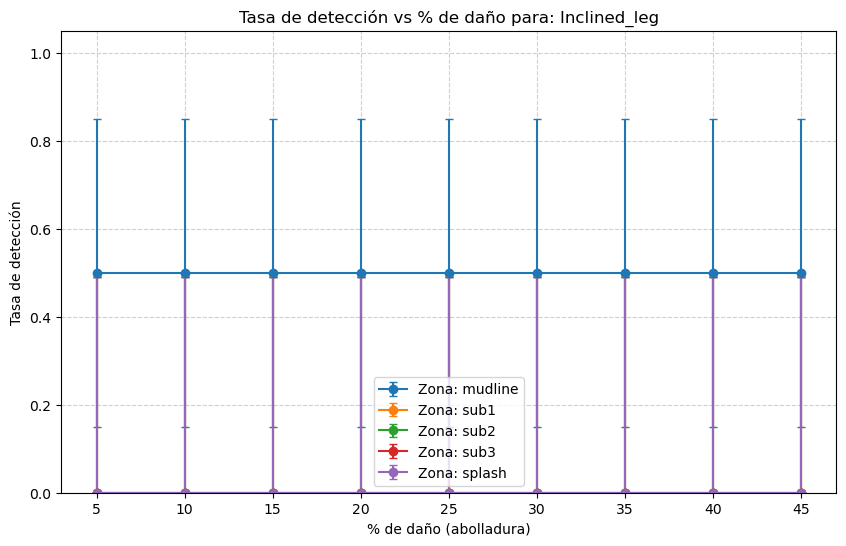

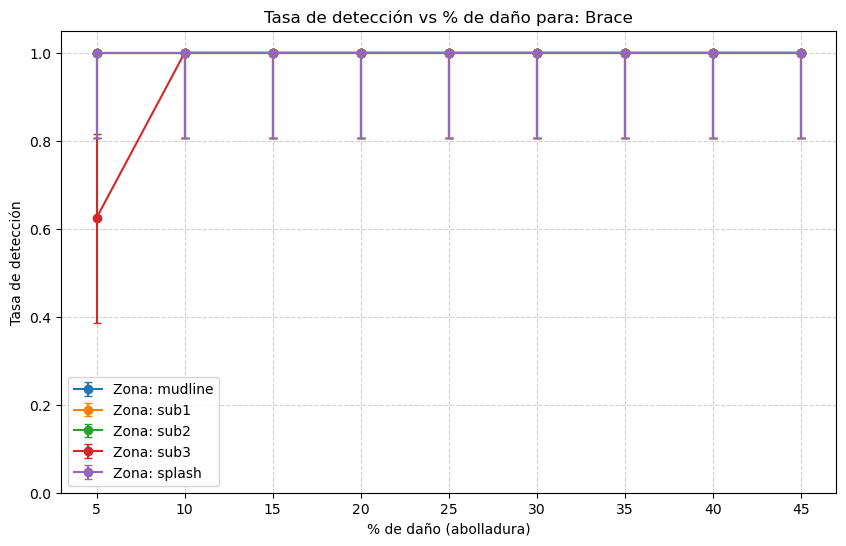

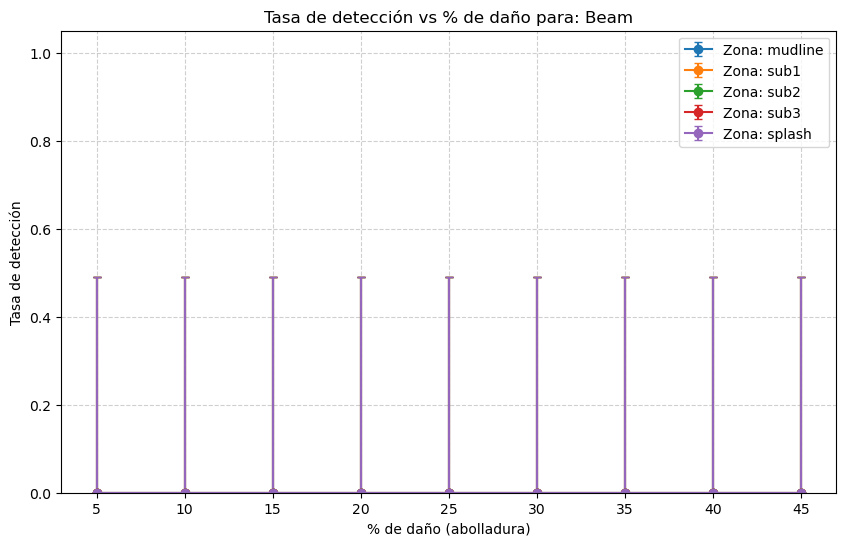


MDD50/MDD90 por Tipo y Zona:
            Tipo     Zona  ok_modelo     MDD50     MDD90
10          Beam  mudline      False       NaN       NaN
14          Beam   splash      False       NaN       NaN
11          Beam     sub1      False       NaN       NaN
12          Beam     sub2      False       NaN       NaN
13          Beam     sub3      False       NaN       NaN
5          Brace  mudline      False       NaN       NaN
9          Brace   splash      False       NaN       NaN
6          Brace     sub1      False       NaN       NaN
7          Brace     sub2      False       NaN       NaN
8          Brace     sub3       True  4.886364  5.375149
0   Inclined_leg  mudline       True       NaN       NaN
4   Inclined_leg   splash      False       NaN       NaN
1   Inclined_leg     sub1      False       NaN       NaN
2   Inclined_leg     sub2      False       NaN       NaN
3   Inclined_leg     sub3      False       NaN       NaN

Resumen GLM con interacción (para contrastar diferencias 

In [6]:
# ---------------------------------------------
# Punto 3 — Extensión espacial del análisis
# Sensibilidad por ZONA (nivel) y cruces con Tipo
# Requiere: pandas, numpy, statsmodels, matplotlib
# ---------------------------------------------
import io, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === Ruta a tu CSV ===
PATH_CSV = "todos_los_resultados_csv.csv"  # ajusta si es necesario

# -------------------------
# 0) Cargar CSV de forma robusta
# (maneja casos con líneas previas tipo "Elemento,Design_Type,Story")
# -------------------------
def robust_read_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    # detecta la fila que inicia con "ID," (cabecera real de resultados)
    start_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().lower().startswith("id,"):
            start_idx = i
            break
    if start_idx is None:
        # carga normal si no encontró un encabezado alterno
        return pd.read_csv(path)
    # lee solo desde la cabecera real
    buf = io.StringIO("".join(lines[start_idx:]))
    return pd.read_csv(buf)

df = robust_read_csv(PATH_CSV)

# -------------------------
# 1) Limpieza y tipos
# -------------------------
# Normaliza etiquetas clave
rename_map = {
    "Tipo_elemento_a_buscar": "Tipo",
    "nivel": "Zona",
    "Porcentaje": "Porcentaje",
    "DeteccionOK": "DeteccionOK",
    "N_FalsosPositivos": "N_FalsosPositivos",
    "MeanAbsDispersion": "MeanAbsDispersion",
    "Design_Type": "Tipo"
}
df = df.rename(columns=rename_map)

# DeteccionOK -> binario
def to_binary(x):
    if isinstance(x, str):
        s = x.strip().upper()
        if s in ("VERDADERO", "TRUE", "1", "SI", "SÍ", "T"):
            return 1
        if s in ("FALSO", "FALSE", "0", "NO", "F"):
            return 0
    if isinstance(x, bool):
        return int(x)
    try:
        return int(x)
    except Exception:
        return np.nan

df["DetOK"] = df["DeteccionOK"].apply(to_binary)

num_cols = ["Porcentaje", "N_FalsosPositivos", "MeanAbsDispersion"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Normaliza Zonas (lowercase, sin espacios) y mapea sinónimos
def norm_zone(z):
    if pd.isna(z): return np.nan
    s = str(z).strip().lower()
    s = re.sub(r"\s+", "", s)
    alias = {
        "mudline": "mudline",
        "mud": "mudline",
        "sub1":"sub1", "submarina1":"sub1","submerged1":"sub1","lowersub":"sub1",
        "sub2":"sub2", "submarina2":"sub2","submerged2":"sub2","midsub":"sub2",
        "sub3":"sub3", "submarina3":"sub3","submerged3":"sub3","uppersub":"sub3",
        "splash":"splash","splashzone":"splash",
        "atm":"atmos","atmosferica":"atmos","atmospheric":"atmos","atmosfera":"atmos",
    }
    return alias.get(s, s)
if 'Zona' in df.columns:
    df["Zona"] = df["Zona"].apply(norm_zone)

# Filtra filas válidas ANTES de convertir a categórica
df = df.dropna(subset=["Tipo", "Porcentaje", "DetOK"])
if 'Zona' in df.columns:
    df = df.dropna(subset=["Zona"])


# Orden lógico de zonas para plots/tablas (solo incluir las que existen en los datos)
all_possible_zones = ["mudline", "sub1", "sub2", "sub3", "splash", "atmos"]
if 'Zona' in df.columns:
    existing_zones = df["Zona"].unique()
    ordered_zones = [z for z in all_possible_zones if z in existing_zones]
    print(f"Zonas encontradas en los datos: {ordered_zones}")
    df["Zona"] = pd.Categorical(df["Zona"], categories=ordered_zones, ordered=True)

existing_tipos = df["Tipo"].unique()
print(f"Tipos de elementos encontrados: {existing_tipos}")


# -------------------------
# 2) Funciones auxiliares
# -------------------------
def wilson_ci(successes, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = successes / n
    denom = 1 + z**2 / n
    center = (p + z**2/(2*n)) / denom
    margin = (z * np.sqrt((p*(1-p)/n) + (z**2)/(4*n**2))) / denom
    return (center - margin, center + margin)

def fit_logit_y_x_binomial(data, y="DetOK", x="Porcentaje"):
    # GLM logit: y ~ x
    m = smf.glm(f"{y} ~ {x}", data=data, family=sm.families.Binomial())
    return m.fit()

def logit(p):
    p = np.clip(p, 1e-6, 1-1e-6)
    return np.log(p/(1-p))

def mdd_and_ci(res, p=0.9, z=1.96, x="Porcentaje"):
    # d = (logit(p) - a) / b
    a = res.params.get("Intercept", np.nan)
    b = res.params.get(x, np.nan)
    if np.isnan(a) or np.isnan(b) or abs(b) < 1e-12:
        return dict(MDD=np.nan, lo=np.nan, hi=np.nan)
    L = logit(p)
    d = (L - a) / b
    cov = res.cov_params()
    var_a = cov.loc["Intercept","Intercept"]
    var_b = cov.loc[x,x]
    cov_ab = cov.loc["Intercept",x]
    dd_da = -1.0 / b
    dd_db = -(L - a) / (b**2)
    var_d = (dd_da**2)*var_a + (dd_db**2)*var_b + 2*dd_da*dd_db*cov_ab
    se_d = np.sqrt(max(var_d, 0.0))
    return dict(MDD=d, lo=d - z*se_d, hi=d + z*se_d)

# ----------------------------------------------------
# 3) Tasa de detección por TIPO × ZONA × PORCENTAJE
# ----------------------------------------------------
grouping_cols = ["Tipo"]
if 'Zona' in df.columns:
    grouping_cols.append("Zona")
grouping_cols.append("Porcentaje")

tasas = (
    df.groupby(grouping_cols, as_index=False, observed=True)
      .agg(n=("DetOK","size"), aciertos=("DetOK","sum"))
)
tasas["tasa"] = tasas["aciertos"] / tasas["n"]
ci = tasas.apply(lambda r: wilson_ci(r["aciertos"], r["n"]), axis=1)
tasas["tasa_lo"] = [c[0] for c in ci]
tasas["tasa_hi"] = [c[1] for c in ci]

print("\nTasa de detección por Tipo x Zona x % (primeras filas):")
print(tasas.head())

# --- Gráficas de tasa por TIPO, con una línea por ZONA ---
for tipo in existing_tipos:
    plt.figure(figsize=(10, 6))
    
    if 'Zona' in df.columns:
        # Graficar por zona si la columna existe
        for zona in ordered_zones:
            sub = tasas[(tasas["Tipo"] == tipo) & (tasas["Zona"] == zona)].sort_values("Porcentaje")
            if sub.empty: 
                continue
            
            yerr = [sub["tasa"] - sub["tasa_lo"], sub["tasa_hi"] - sub["tasa"]]
            plt.errorbar(sub["Porcentaje"], sub["tasa"], yerr=yerr, fmt="-o", capsize=3, label=f"Zona: {zona}")
        plt.legend()

    else:
        # Graficar solo por tipo si la columna Zona no existe
        sub = tasas[tasas["Tipo"] == tipo].sort_values("Porcentaje")
        if not sub.empty:
            yerr = [sub["tasa"] - sub["tasa_lo"], sub["tasa_hi"] - sub["tasa"]]
            plt.errorbar(sub["Porcentaje"], sub["tasa"], yerr=yerr, fmt="-o", capsize=3)

    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Tasa de detección")
    plt.title(f"Tasa de detección vs % de daño para: {tipo}")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

# ----------------------------------------------------
# 4) Curvas POD y MDD por TIPO y ZONA
# ----------------------------------------------------
if 'Zona' in df.columns:
    mdd_rows = []
    for tipo in existing_tipos:
        for zona in ordered_zones:
            sub_raw = df[(df["Tipo"] == tipo) & (df["Zona"] == zona)]
            
            if sub_raw.empty or sub_raw["DetOK"].nunique() < 2 or sub_raw["Porcentaje"].nunique() < 2:
                mdd_rows.append({"Tipo": tipo, "Zona": zona, "ok_modelo": False,
                                 "MDD50": np.nan, "MDD90": np.nan})
                continue
            
            try:
                res = fit_logit_y_x_binomial(sub_raw, y="DetOK", x="Porcentaje")
                m50 = mdd_and_ci(res, p=0.50, x="Porcentaje")
                m90 = mdd_and_ci(res, p=0.90, x="Porcentaje")
                mdd_rows.append({"Tipo": tipo, "Zona": zona, "ok_modelo": True,
                                 "MDD50": m50["MDD"], "MDD90": m90["MDD"]})
            except Exception as e:
                print(f"[{tipo} - {zona}] Problema al ajustar GLM:", e)
                mdd_rows.append({"Tipo": tipo, "Zona": zona, "ok_modelo": False,
                                 "MDD50": np.nan, "MDD90": np.nan})

    tabla_mdd_tipo_zona = pd.DataFrame(mdd_rows).sort_values(["Tipo", "Zona"])
    print("\nMDD50/MDD90 por Tipo y Zona:")
    print(tabla_mdd_tipo_zona)

# ----------------------------------------------------
# 5) Modelo conjunto con interacción (opcional)
# ----------------------------------------------------
try:
    df2 = df.dropna(subset=["Porcentaje","DetOK"]).copy()
    if 'Zona' in df2.columns:
        df2 = df2.dropna(subset=["Zona"])
        df2["Zona"] = df2["Zona"].astype("category")
    df2["Tipo"] = df2["Tipo"].astype("category")

    formula = "DetOK ~ Porcentaje"
    if 'Zona' in df2.columns:
        formula += " * C(Zona)"
    formula += " * C(Tipo)"
    
    m_int = smf.glm(formula, data=df2, family=sm.families.Binomial()).fit()
    print("\nResumen GLM con interacción (para contrastar diferencias por Zona/Tipo):")
    print(m_int.summary())
except Exception as e:
    print("\nNo se pudo ajustar el modelo conjunto con interacción:", e)


Resumen del Índice de Calidad de Detección (ICD) por Tipo y Porcentaje:
   Tipo_elemento_a_buscar  Porcentaje  icd_mean   icd_std   n  icd_ci_half  \
0                    Beam           5  0.000000  0.000000  20     0.000000   
1                    Beam          10  0.000000  0.000000  20     0.000000   
2                    Beam          15  0.000000  0.000000  20     0.000000   
3                    Beam          20  0.000000  0.000000  20     0.000000   
4                    Beam          25  0.000000  0.000000  20     0.000000   
5                    Beam          30  0.000000  0.000000  20     0.000000   
6                    Beam          35  0.000000  0.000000  20     0.000000   
7                    Beam          40  0.000000  0.000000  20     0.000000   
8                    Beam          45  0.000000  0.000000  20     0.000000   
9                   Brace           5  0.154995  0.068138  80     0.014931   
10                  Brace          10  0.166051  0.041263  80     0.00

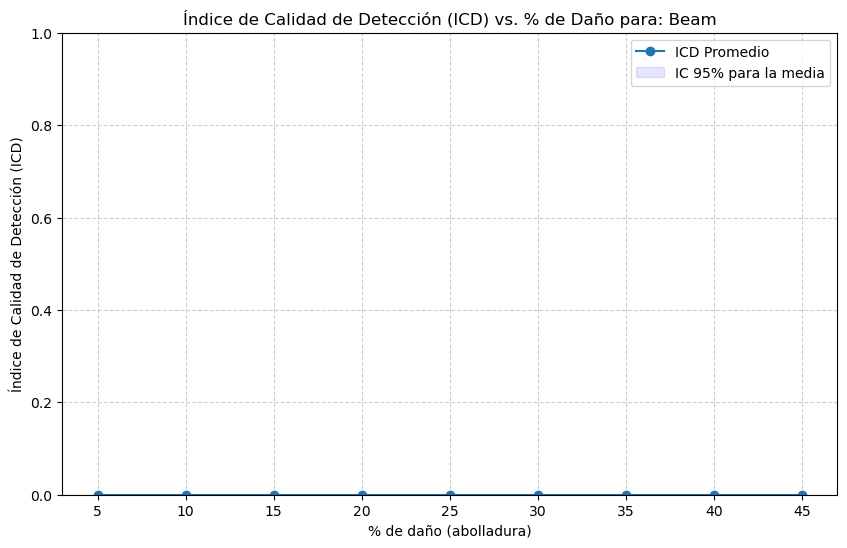

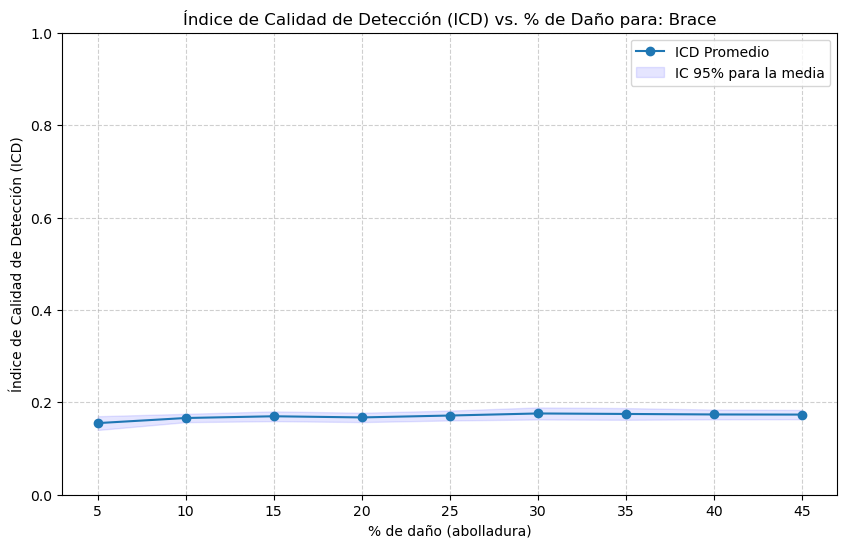

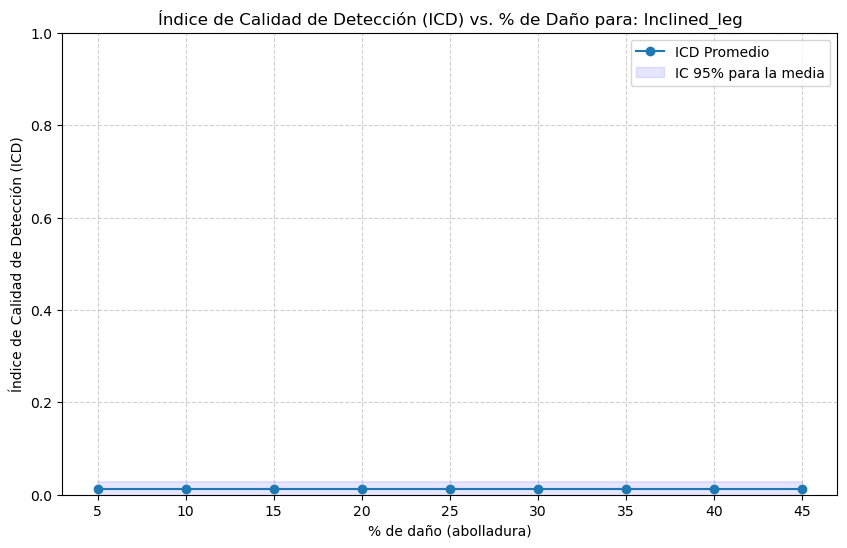

In [7]:
# -----------------------------------------------------------------
# Punto 4 — Análisis Inverso: Calidad de Detección vs. Severidad
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- Cargar y preprocesar datos (similar a los puntos anteriores) ---
PATH_CSV = "todos_los_resultados_csv.csv"
df = pd.read_csv(PATH_CSV)

# Renombrar y limpiar
rename_map = {
    "Design_Type": "Tipo_elemento_a_buscar",
    "DeteccionOK": "DeteccionOK",
    "MeanAbsDispersion": "MeanAbsDispersion",
    "N_FalsosPositivos": "N_FalsosPositivos",
    "Porcentaje": "Porcentaje"
}
df = df.rename(columns=rename_map)

# Convertir DeteccionOK a binario
def to_binary(x):
    if isinstance(x, str):
        s = x.strip().upper()
        return 1 if s in ("VERDADERO", "TRUE", "1", "SI", "SÍ", "T") else 0
    if isinstance(x, bool):
        return int(x)
    return int(x) if pd.notna(x) else np.nan

df["DetOK"] = df["DeteccionOK"].apply(to_binary)

# Asegurar tipos numéricos
num_cols = ["Porcentaje", "N_FalsosPositivos", "MeanAbsDispersion", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Eliminar filas con datos faltantes en columnas clave
df = df.dropna(subset=["Tipo_elemento_a_buscar", "Porcentaje", "DetOK", "MeanAbsDispersion", "N_FalsosPositivos"])

# --- Calcular el Índice de Calidad de Detección (ICD) ---
# El "+1" en el denominador evita divisiones por cero si la localización es perfecta
df["ICD"] = df["DetOK"] * (1 / (1 + df["MeanAbsDispersion"] + df["N_FalsosPositivos"]))

# --- Agrupar por Tipo y Porcentaje para análisis ---
# Usamos 'agg' para calcular media, conteo y error estándar de la media (sem)
summary = df.groupby(["Tipo_elemento_a_buscar", "Porcentaje"]).agg(
    icd_mean=('ICD', 'mean'),
    icd_std=('ICD', 'std'),
    n=('ICD', 'size')
).reset_index()

# Calcular el intervalo de confianza del 95% para la media
# IC = media ± z * (std / sqrt(n))
# Para n>30, z≈1.96. Si n es pequeño, se podría usar t-student, pero z es una buena aprox.
z_score = 1.96
summary['icd_ci_half'] = z_score * (summary['icd_std'] / np.sqrt(summary['n']))
summary['icd_ci_lo'] = summary['icd_mean'] - summary['icd_ci_half']
summary['icd_ci_hi'] = summary['icd_mean'] + summary['icd_ci_half']

print("Resumen del Índice de Calidad de Detección (ICD) por Tipo y Porcentaje:")
print(summary)

# --- Generar gráficas ---
tipos_elementos = summary["Tipo_elemento_a_buscar"].unique()

for tipo in tipos_elementos:
    subset = summary[summary["Tipo_elemento_a_buscar"] == tipo].sort_values("Porcentaje")
    
    if subset.empty:
        continue
        
    plt.figure(figsize=(10, 6))
    
    # Media del ICD
    plt.plot(subset["Porcentaje"], subset["icd_mean"], marker='o', linestyle='-', label="ICD Promedio")
    
    # Banda de confianza del 95%
    plt.fill_between(subset["Porcentaje"], subset["icd_ci_lo"], subset["icd_ci_hi"], color='b', alpha=0.1, label="IC 95% para la media")
    
    plt.title(f"Índice de Calidad de Detección (ICD) vs. % de Daño para: {tipo}")
    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Índice de Calidad de Detección (ICD)")
    plt.ylim(0, max(1.0, summary['icd_ci_hi'].max() * 1.1)) # Ajustar límite superior
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()


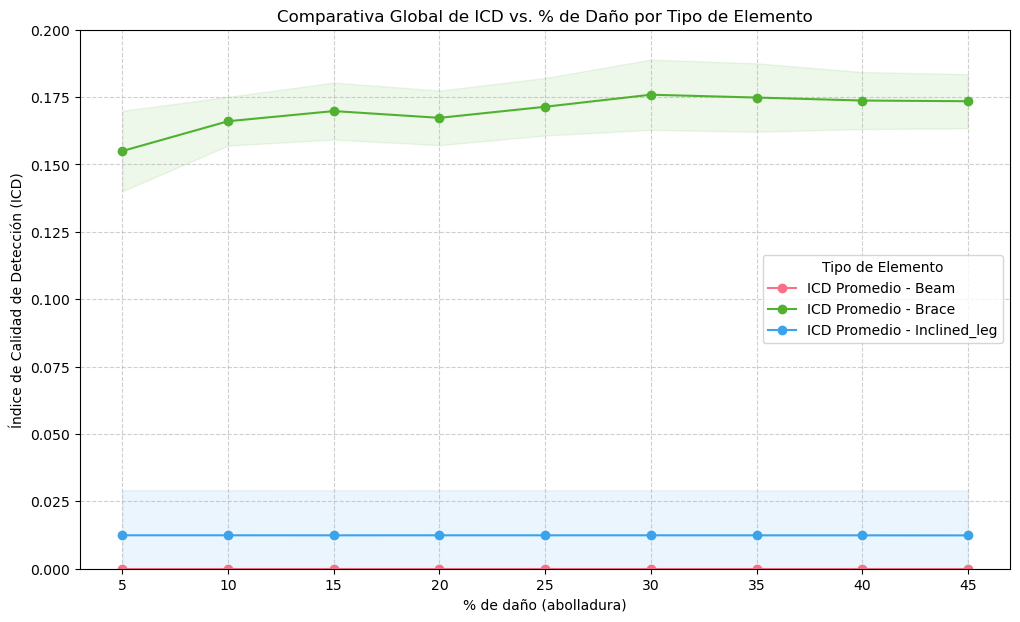

In [8]:
# -----------------------------------------------------------------
# Punto 4.5 — Gráfica Comparativa Global de ICD
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Re-cálculo de datos para que la celda sea autocontenida ---
# (Este código es idéntico al de la celda anterior para asegurar la disponibilidad de `summary`)
PATH_CSV = "todos_los_resultados_csv.csv"
df = pd.read_csv(PATH_CSV)

rename_map = {
    "Design_Type": "Tipo_elemento_a_buscar",
    "DeteccionOK": "DeteccionOK",
    "MeanAbsDispersion": "MeanAbsDispersion",
    "N_FalsosPositivos": "N_FalsosPositivos",
    "Porcentaje": "Porcentaje"
}
df = df.rename(columns=rename_map)

def to_binary(x):
    if isinstance(x, str):
        s = x.strip().upper()
        return 1 if s in ("VERDADERO", "TRUE", "1", "SI", "SÍ", "T") else 0
    if isinstance(x, bool):
        return int(x)
    return int(x) if pd.notna(x) else np.nan

df["DetOK"] = df["DeteccionOK"].apply(to_binary)

num_cols = ["Porcentaje", "N_FalsosPositivos", "MeanAbsDispersion", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["Tipo_elemento_a_buscar", "Porcentaje", "DetOK", "MeanAbsDispersion", "N_FalsosPositivos"])

df["ICD"] = df["DetOK"] * (1 / (1 + df["MeanAbsDispersion"] + df["N_FalsosPositivos"]))

summary = df.groupby(["Tipo_elemento_a_buscar", "Porcentaje"]).agg(
    icd_mean=('ICD', 'mean'),
    icd_std=('ICD', 'std'),
    n=('ICD', 'size')
).reset_index()

z_score = 1.96
summary['icd_ci_half'] = z_score * (summary['icd_std'] / np.sqrt(summary['n']))
summary['icd_ci_lo'] = summary['icd_mean'] - summary['icd_ci_half']
summary['icd_ci_hi'] = summary['icd_mean'] + summary['icd_ci_half']

# --- Generar la gráfica consolidada ---
plt.figure(figsize=(12, 7))
tipos_elementos = summary["Tipo_elemento_a_buscar"].unique()

# Usar una paleta de colores para distinguir los tipos
palette = sns.color_palette("husl", len(tipos_elementos))

for i, tipo in enumerate(tipos_elementos):
    subset = summary[summary["Tipo_elemento_a_buscar"] == tipo].sort_values("Porcentaje")
    
    if subset.empty:
        continue
    
    # Curva de la media del ICD
    plt.plot(subset["Porcentaje"], subset["icd_mean"], marker='o', linestyle='-', label=f"ICD Promedio - {tipo}", color=palette[i])
    
    # Banda de confianza del 95%
    plt.fill_between(subset["Porcentaje"], subset["icd_ci_lo"], subset["icd_ci_hi"], color=palette[i], alpha=0.1)

plt.title("Comparativa Global de ICD vs. % de Daño por Tipo de Elemento")
plt.xlabel("% de daño (abolladura)")
plt.ylabel("Índice de Calidad de Detección (ICD)")
plt.ylim(0, 0.2)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Tipo de Elemento")
plt.show()

Resumen del Índice de Calidad de Detección (ICD) por Zona y Porcentaje:
       Zona  Porcentaje  icd_mean   icd_std   n  icd_ci_half  icd_ci_lo  \
0   mudline           5  0.104286  0.068499  24     0.027405   0.076881   
1   mudline          10  0.103417  0.067778  24     0.027117   0.076301   
2   mudline          15  0.100847  0.066318  24     0.026533   0.074315   
3   mudline          20  0.096698  0.065072  24     0.026034   0.070664   
4   mudline          25  0.095875  0.066496  24     0.026604   0.069271   
5   mudline          30  0.097565  0.070407  24     0.028169   0.069396   
6   mudline          35  0.097936  0.071567  24     0.028633   0.069304   
7   mudline          40  0.098338  0.072507  24     0.029009   0.069329   
8   mudline          45  0.098669  0.073284  24     0.029320   0.069349   
9    splash           5  0.097787  0.073616  24     0.029453   0.068334   
10   splash          10  0.099785  0.075677  24     0.030277   0.069507   
11   splash          15  0.1

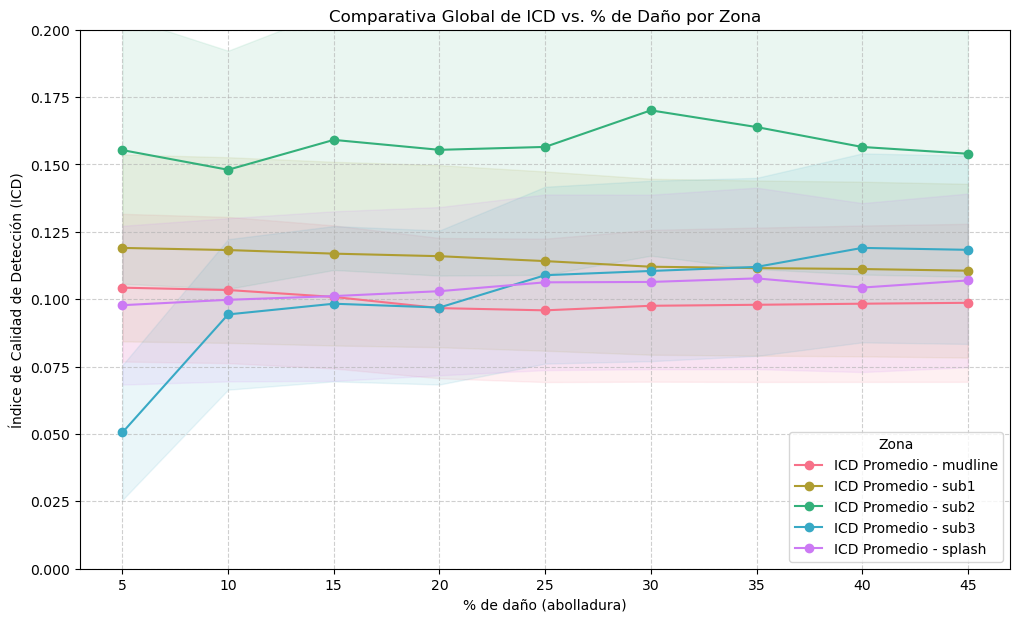

In [9]:
# -----------------------------------------------------------------
# Punto 5 — Análisis de ICD por Zona (nivel)
# -----------------------------------------------------------------
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Cargar CSV ---
PATH_CSV = "todos_los_resultados_csv.csv"

def robust_read_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    start_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().lower().startswith("id,"):
            start_idx = i
            break
    if start_idx is None:
        return pd.read_csv(path)
    buf = io.StringIO("".join(lines[start_idx:]))
    return pd.read_csv(buf)

df = robust_read_csv(PATH_CSV)

# --- Renombrar columnas ---
rename_map = {
    "Design_Type": "Tipo",
    "nivel": "Zona",
    "DeteccionOK": "DeteccionOK",
    "MeanAbsDispersion": "MeanAbsDispersion",
    "N_FalsosPositivos": "N_FalsosPositivos",
    "Porcentaje": "Porcentaje"
}
df = df.rename(columns=rename_map)

# --- Convertir DeteccionOK a binario ---
def to_binary(x):
    if isinstance(x, str):
        s = x.strip().upper()
        return 1 if s in ("VERDADERO", "TRUE", "1", "SI", "SÍ", "T") else 0
    if isinstance(x, bool):
        return int(x)
    return int(x) if pd.notna(x) else np.nan

df["DetOK"] = df["DeteccionOK"].apply(to_binary)

# --- Asegurar tipos numéricos ---
num_cols = ["Porcentaje", "N_FalsosPositivos", "MeanAbsDispersion", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- Normalizar Zonas ---
def norm_zone(z):
    if pd.isna(z): 
        return np.nan
    s = str(z).strip().lower()
    s = re.sub(r"\s+", "", s)
    alias = {
        "mudline": "mudline", "mud": "mudline",
        "sub1":"sub1", "submarina1":"sub1", "submerged1":"sub1", "lowersub":"sub1",
        "sub2":"sub2", "submarina2":"sub2", "submerged2":"sub2", "midsub":"sub2",
        "sub3":"sub3", "submarina3":"sub3", "submerged3":"sub3", "uppersub":"sub3",
        "splash":"splash", "splashzone":"splash",
        "atm":"atmos", "atmosferica":"atmos", "atmospheric":"atmos", "atmosfera":"atmos",
    }
    return alias.get(s, s)

if 'Zona' in df.columns:
    df["Zona"] = df["Zona"].apply(norm_zone)

# --- Filtrar filas válidas ---
required_cols = ["Zona", "Porcentaje", "DetOK", "MeanAbsDispersion", "N_FalsosPositivos"]
df = df.dropna(subset=required_cols)

# --- Verificar si existen zonas ---
if 'Zona' not in df.columns or df['Zona'].isna().all():
    print("⚠️ La columna 'Zona' no existe o no contiene datos válidos en el CSV.")
else:
    # --- Calcular el Índice de Calidad de Detección (ICD) ---
    df["ICD"] = df["DetOK"] * (1 / (1 + df["MeanAbsDispersion"] + df["N_FalsosPositivos"]))

    # --- Agrupar por Zona y Porcentaje ---
    summary_zona = df.groupby(["Zona", "Porcentaje"]).agg(
        icd_mean=('ICD', 'mean'),
        icd_std=('ICD', 'std'),
        n=('ICD', 'size')
    ).reset_index()

    # --- Calcular IC 95% ---
    z_score = 1.96
    summary_zona['icd_ci_half'] = z_score * (summary_zona['icd_std'] / np.sqrt(summary_zona['n']))
    summary_zona['icd_ci_lo'] = summary_zona['icd_mean'] - summary_zona['icd_ci_half']
    summary_zona['icd_ci_hi'] = summary_zona['icd_mean'] + summary_zona['icd_ci_half']

    print("Resumen del Índice de Calidad de Detección (ICD) por Zona y Porcentaje:")
    print(summary_zona)

    # --- Generar la gráfica consolidada por Zona ---
    plt.figure(figsize=(12, 7))
    
    # Definir orden lógico de zonas
    all_possible_zones = ["mudline", "sub1", "sub2", "sub3", "splash", "atmos"]
    existing_zones = [z for z in all_possible_zones if z in summary_zona["Zona"].unique()]
    
    print(f"\nZonas encontradas: {existing_zones}")
    
    # Usar una paleta de colores
    palette = sns.color_palette("husl", len(existing_zones))

    for i, zona in enumerate(existing_zones):
        subset = summary_zona[summary_zona["Zona"] == zona].sort_values("Porcentaje")
        
        if subset.empty:
            continue
        
        # Curva de la media del ICD
        plt.plot(subset["Porcentaje"], subset["icd_mean"], marker='o', linestyle='-', 
                 label=f"ICD Promedio - {zona}", color=palette[i])
        
        # Banda de confianza del 95%
        plt.fill_between(subset["Porcentaje"], subset["icd_ci_lo"], subset["icd_ci_hi"], 
                         color=palette[i], alpha=0.1)

    plt.title("Comparativa Global de ICD vs. % de Daño por Zona")
    plt.xlabel("% de daño (abolladura)")
    plt.ylabel("Índice de Calidad de Detección (ICD)")
    plt.ylim(0, 0.2)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Zona")
    plt.show()


### Explicación de la Fórmula del Índice de Calidad de Detección (ICD)

La fórmula utilizada para medir la calidad de la detección es:

$$\text{ICD} = \text{DetOK} \times \frac{1}{1 + \text{MeanAbsDispersion} + N_{\text{FalsosPositivos}}}$$

O en su forma abreviada:

$$\text{ICD} = D \times \frac{1}{1 + \bar{d} + N_{FP}}$$

A continuación se detalla cada componente y cómo se obtiene a partir del código:

*   **`ICD` (Índice de Calidad de Detección):** Es la métrica final que evalúa el rendimiento de la detección. Un valor más alto indica una mejor calidad. Se calcula para cada una de las detecciones individuales (cada fila del `DataFrame`).

*   **`DetOK` (Detección Correcta, D):** Es un valor binario que indica si la detección fue exitosa.
    *   **Valor:** `1` si la detección fue correcta, `0` si no lo fue.
    *   **Cálculo en el código:** Se deriva de la columna `DeteccionOK`. La función `to_binary` convierte valores de texto como "VERDADERO", "TRUE", "SI" o "1" en el valor numérico `1`, y cualquier otro caso en `0`. Si la detección no es correcta (`DetOK = 0`), todo el ICD se anula, penalizando fuertemente el fallo.

*   **`MeanAbsDispersion` (Dispersión Absoluta Media, `d̄`):** Representa la desviación promedio de las mediciones con respecto al valor real.
    *   **Valor:** Es un número de punto flotante que indica qué tan dispersos están los puntos de la detección.
    *   **Cálculo en el código:** Se obtiene directamente de la columna `MeanAbsDispersion` del archivo CSV. Actúa como un término de penalización: a mayor dispersión, menor será el valor del ICD.

*   **`N_FalsosPositivos` (Número de Falsos Positivos, `N_FP`):** Es el recuento de detecciones incorrectas que el sistema identificó como válidas.
    *   **Valor:** Un número entero que representa la cantidad de falsos positivos.
    *   **Cálculo en el código:** Se toma de la columna `N_FalsosPositivos`. Al igual que la dispersión, es un término de penalización. Un mayor número de falsos positivos reduce el valor del ICD.

La línea de código clave que implementa esta fórmula es:

```python
df["ICD"] = df["DetOK"] * (1 / (1 + df["MeanAbsDispersion"] + df["N_FalsosPositivos"]))
```

Finalmente, para generar la gráfica, los valores de `ICD` se agrupan por `Zona` y `Porcentaje`, y se calcula la media (`icd_mean`) y el intervalo de confianza para visualizar la tendencia central y la variabilidad del rendimiento de la detección en diferentes condiciones.

### Punto 15 — Análisis de ICD por Zona, desglosado por Tipo de Elemento

En el análisis anterior del Punto 14, se observó el comportamiento del ICD promediado para cada zona, pero sin diferenciar entre los tipos de elementos estructurales. Este nuevo análisis desglosa los resultados para proporcionar una visión más detallada.

Para cada zona (`mudline`, `sub1`, `sub2`, `sub3`, `splash`), se genera una gráfica individual que muestra la evolución del ICD frente al porcentaje de daño. Dentro de cada gráfica, se trazan curvas separadas para cada `Tipo_elemento_a_buscar` (`Brace`, `Inclined_leg`, `Beam`).

Este enfoque permite responder a preguntas más específicas:
- ¿El `Brace` se comporta de manera diferente en la `splash` zone en comparación con la `mudline`?
- ¿La calidad de detección del `Inclined_leg` es consistente a través de las diferentes zonas submarinas?
- ¿Hay algún tipo de elemento cuyo rendimiento sea particularmente sensible a una zona específica?

La siguiente celda de código implementa este análisis, generando una matriz de gráficas para una comparación visual directa y detallada.

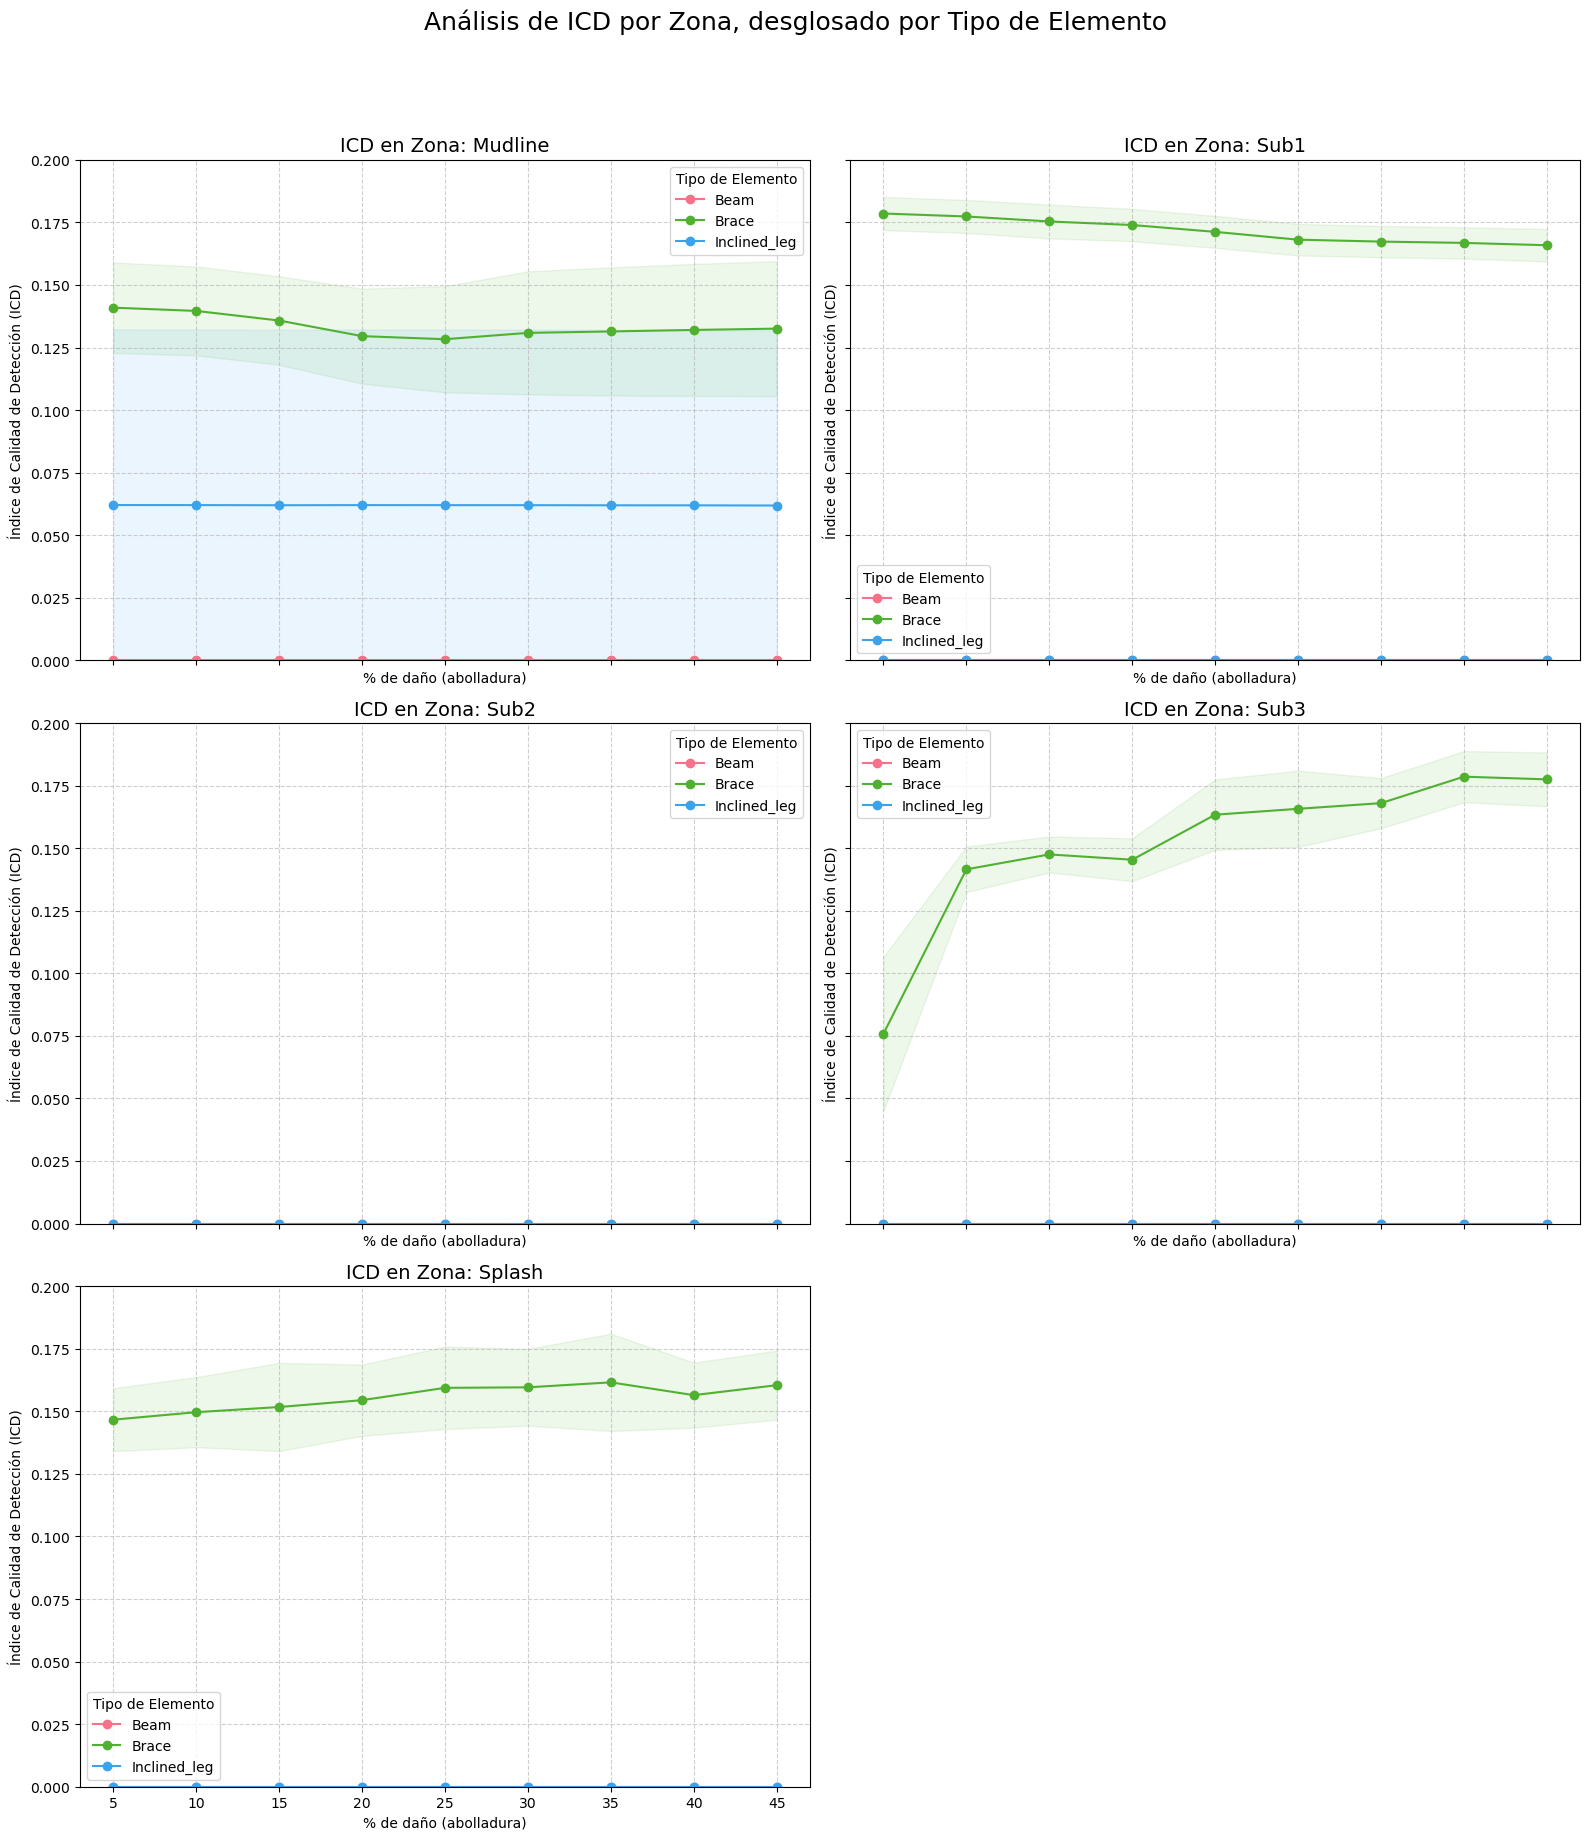

In [10]:
# -----------------------------------------------------------------
# Punto 6s — Análisis de ICD por Zona, desglosado por Tipo de Elemento
# -----------------------------------------------------------------
import io
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# --- Cargar y preparar datos (similar a celdas anteriores) ---
PATH_CSV = "todos_los_resultados_csv.csv"

def robust_read_csv(path):
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    start_idx = None
    for i, ln in enumerate(lines):
        if ln.strip().lower().startswith("id,"):
            start_idx = i
            break
    if start_idx is None: return pd.read_csv(path)
    buf = io.StringIO("".join(lines[start_idx:]))
    return pd.read_csv(buf)

df = robust_read_csv(PATH_CSV)

rename_map = {
    "nivel": "Zona",
    "Tipo_elemento_a_buscar": "TipoDeElemento", # CORREGIDO: Nombre único para evitar conflicto
    "Porcentaje": "Porcentaje",
    "DeteccionOK": "DeteccionOK",
    "MeanAbsDispersion": "MeanAbsDispersion",
    "N_FalsosPositivos": "N_FalsosPositivos"
}
df = df.rename(columns=rename_map)

def to_binary(x):
    if isinstance(x, str):
        s = x.strip().upper()
        return 1 if s in ("VERDADERO", "TRUE", "1", "SI", "SÍ", "T") else 0
    return int(x) if pd.notna(x) and isinstance(x, bool) else (int(x) if pd.notna(x) else np.nan)

df["DetOK"] = df["DeteccionOK"].apply(to_binary)

num_cols = ["Porcentaje", "N_FalsosPositivos", "MeanAbsDispersion", "DetOK"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

def norm_zone(z):
    if pd.isna(z): return np.nan
    s = str(z).strip().lower()
    s = re.sub(r"\s+", "", s)
    alias = {
        "mudline": "mudline", "mud": "mudline",
        "sub1":"sub1", "submarina1":"sub1",
        "sub2":"sub2", "submarina2":"sub2",
        "sub3":"sub3", "submarina3":"sub3",
        "splash":"splash", "splashzone":"splash",
    }
    return alias.get(s, s)

if 'Zona' in df.columns:
    df["Zona"] = df["Zona"].apply(norm_zone)

required_cols = ["Zona", "TipoDeElemento", "Porcentaje", "DetOK", "MeanAbsDispersion", "N_FalsosPositivos"]
df_filtered = df.dropna(subset=required_cols)

# --- Calcular ICD ---
df_filtered["ICD"] = df_filtered["DetOK"] * (1 / (1 + df_filtered["MeanAbsDispersion"] + df_filtered["N_FalsosPositivos"]))

# --- Agrupar por Zona, Elemento y Porcentaje ---
summary = df_filtered.groupby(["Zona", "TipoDeElemento", "Porcentaje"]).agg(
    icd_mean=('ICD', 'mean'),
    icd_std=('ICD', 'std'),
    n=('ICD', 'size')
).reset_index()

z_score = 1.96
summary['icd_ci_half'] = z_score * (summary['icd_std'] / np.sqrt(summary['n']))
summary['icd_ci_lo'] = summary['icd_mean'] - summary['icd_ci_half']
summary['icd_ci_hi'] = summary['icd_mean'] + summary['icd_ci_half']

# --- Generar una gráfica por cada Zona ---
zonas_ordenadas = ["mudline", "sub1", "sub2", "sub3", "splash"]
zonas_existentes = [z for z in zonas_ordenadas if z in summary["Zona"].unique()]
elementos_existentes = summary["TipoDeElemento"].unique()

if not zonas_existentes:
    print("⚠️ No se encontraron datos de zonas para graficar.")
else:
    # --- Configuración de subplots ---
    n_zonas = len(zonas_existentes)
    n_cols = 2
    n_rows = math.ceil(n_zonas / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 6), sharex=True, sharey=True)
    axes = axes.flatten() # Aplanar el array de ejes para iterar fácilmente

    palette = sns.color_palette("husl", len(elementos_existentes))
    element_color_map = {elem: palette[i] for i, elem in enumerate(elementos_existentes)}

    for i, zona in enumerate(zonas_existentes):
        ax = axes[i]
        ax.set_title(f"ICD en Zona: {zona.capitalize()}", fontsize=14)
        
        for elemento in elementos_existentes:
            subset = summary[(summary["Zona"] == zona) & (summary["TipoDeElemento"] == elemento)].sort_values("Porcentaje")
            
            if not subset.empty:
                color = element_color_map[elemento]
                ax.plot(subset["Porcentaje"], subset["icd_mean"], marker='o', linestyle='-', 
                        label=elemento, color=color)
                ax.fill_between(subset["Porcentaje"], subset["icd_ci_lo"], subset["icd_ci_hi"], 
                                color=color, alpha=0.1)

        ax.set_ylabel("Índice de Calidad de Detección (ICD)")
        ax.set_xlabel("% de daño (abolladura)")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(title="Tipo de Elemento")
        ax.set_ylim(0, 0.2) # Mantener la misma escala Y que en gráficas anteriores

    # Ocultar ejes no utilizados
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("Análisis de ICD por Zona, desglosado por Tipo de Elemento", fontsize=18, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
